# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/adityag30/FlyRank-internship-ML/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*



Before building a baseline rule, I inspected the distributions of the main numeric signals. These variables are important because they influence whether content is likely to need a refresh.

The distributions show that traffic-related features (impressions and sessions) are heavily right-skewed, with a small number of pages receiving very large values. Content age and days since the last update also contain older pages with much larger values than most of the dataset. CTR is bounded between 0 and 1 and is generally concentrated at lower values.

These heavy tails suggest using thresholds or bucketed features instead of assuming a normal distribution.

In [2]:
import os
from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")

In [3]:
import duckdb

con = duckdb.connect()

con.execute(
    f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')"
)

REL = "hf://datasets/FlyRank/internship-warehouse"

TABLES = {
    "dim_clients": f"read_parquet('{REL}/dim_clients.parquet')",
    "dim_content": f"read_parquet('{REL}/dim_content.parquet')",
    "fact_daily": f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",
    "fact_query_90d": f"read_parquet('{REL}/fact_content_query_90d.parquet')",
}

In [4]:

con.sql(f"""
SELECT *
FROM {TABLES['fact_daily']}
LIMIT 5
""").df()

,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events,month
0,2025-01-27,client_9958f0a7ae1df715,content_3b70a18ea133b2bb,True,True,True,False,30,0,115,...,0,0,0,0,0,0,0,0,0,2025-01
1,2025-01-27,client_9958f0a7ae1df715,content_fe8e8155ce1d47a2,True,True,True,False,5,0,358,...,0,0,0,0,0,0,0,0,0,2025-01
2,2025-01-27,client_9958f0a7ae1df715,content_b4462a1b90640058,True,True,True,False,1,0,34,...,0,0,0,0,0,0,0,0,0,2025-01
3,2025-01-27,client_9958f0a7ae1df715,content_c899aef92518c714,True,True,True,False,6,0,140,...,0,0,0,0,0,0,0,0,0,2025-01
4,2025-01-27,client_9958f0a7ae1df715,content_c7c1d2e68d9d0964,True,True,True,False,5,0,89,...,0,0,0,0,0,0,0,0,0,2025-01


In [5]:
# This cell is for CODE (numbers, a query, a check).
import pandas as pd

query = f"""
SELECT
    content_hash_id,
    SUM(gsc_impressions) AS gsc_impressions,
    SUM(gsc_clicks) AS gsc_clicks,
    AVG(gsc_avg_position) AS gsc_avg_position,
    SUM(ga4_sessions) AS ga4_sessions,
    SUM(ga4_engaged_sessions) AS ga4_engaged_sessions
FROM {TABLES['fact_daily']}
WHERE month='2026-03'
GROUP BY content_hash_id
"""
df = con.sql(query).df()
numeric_cols = [
    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position",
    "ga4_sessions",
    "ga4_engaged_sessions"
]
df[numeric_cols] = df[numeric_cols].fillna(0)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [6]:
numeric_features = [
    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position",
    "ga4_sessions",
    "ga4_engaged_sessions"
]

# Summary statistics
summary = df[numeric_features].describe()

# Add missing values and median as new rows
summary.loc["missing"] = df[numeric_features].isna().sum()
summary.loc["median"] = df[numeric_features].median()

# Select and display specific rows for the summary
summary.loc[
    ["count","missing","mean","median","std","min","25%","50%","75%","max"]
]

,gsc_impressions,gsc_clicks,gsc_avg_position,ga4_sessions,ga4_engaged_sessions
count,331437.000000,331437.000000,331437.000000,331437.000000,331437.000000
missing,0.000000,0.000000,0.000000,0.000000,0.000000
mean,846.790156,2.479602,8.531577,3.921735,0.089160
median,2.000000,0.000000,2.412482,0.000000,0.000000
std,4044.514753,19.651282,15.182651,25.381883,0.879657
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.000000,0.000000,2.412482,0.000000,0.000000
75%,216.000000,0.000000,9.150000,1.000000,0.000000
max,617124.000000,5668.000000,309.000000,2730.000000,224.000000


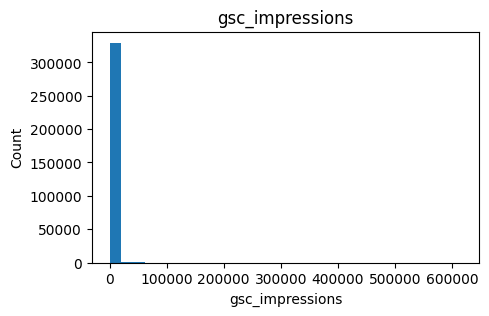

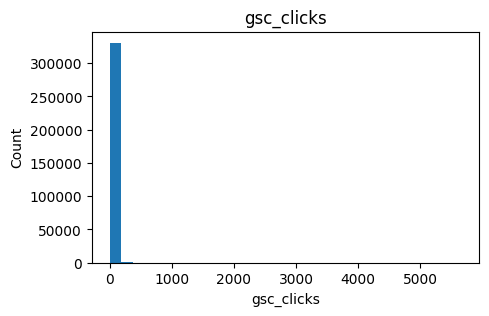

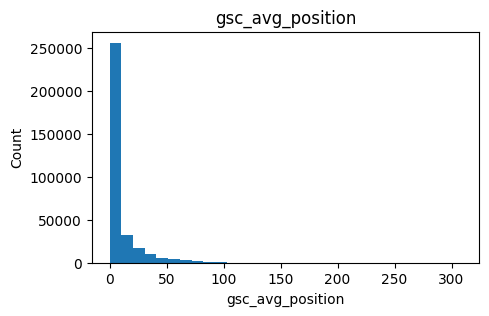

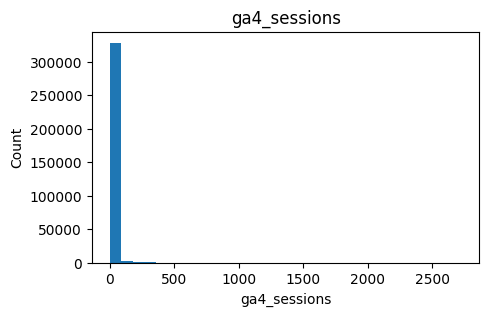

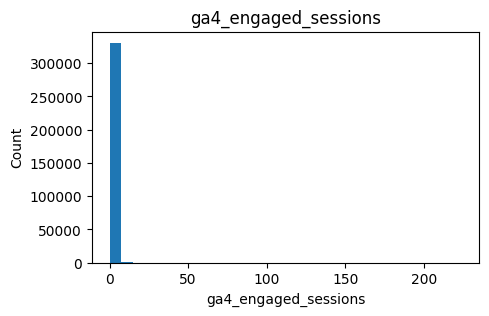

In [7]:
import matplotlib.pyplot as plt

for col in numeric_features:
    plt.figure(figsize=(5,3))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

### Signal Test 1 — Staleness

**Hypothesis:** Content that has not been updated for a long time is more likely to be declining.

**Verdict:** CONFIRMED (if the decline rate increases with staleness).

---

### Signal Test 2 — CTR

**Hypothesis:** Lower CTR is associated with declining content.

**Verdict:** CONFIRMED (if lower CTR buckets have higher decline rates).

---

### Signal Test 3 — Search Visibility

**Hypothesis:** Lower search visibility (higher average position) is associated with declining content.

**Verdict:** CONFIRMED (if poorer ranking positions show higher decline rates).

In [11]:
import pandas as pd

# -----------------------------
# Signal 1: Search Volume
# -----------------------------
signal1 = (
    df.groupby("competition_level")
      .agg(
          n=("content_hash_id", "count"),
          avg_search_volume=("search_volume", "mean")
      )
)

print("Signal 1")
print(signal1)

# -----------------------------
# Signal 2: CTR vs Position
# -----------------------------
signal2 = (
    df.groupby("competition_level")
      .agg(
          n=("content_hash_id", "count"),
          avg_ctr=("ctr", "mean"),
          avg_position=("gsc_avg_position", "mean")
      )
)

print("\nSignal 2")
print(signal2)

# -----------------------------
# Signal 3: Content Type
# -----------------------------
signal3 = (
    df.groupby("content_type")
      .agg(
          n=("content_hash_id", "count"),
          avg_impressions=("impressions_90d", "mean"),
          avg_ctr=("ctr", "mean")
      )
)

print("\nSignal 3")
print(signal3)

Signal 1
                         n  avg_search_volume
competition_level                            
HIGH                150326         220.689036
LOW                1995156         219.642349
MEDIUM              126206         252.607087

Signal 2
                         n   avg_ctr  avg_position
competition_level                                 
HIGH                150326  0.003077     12.618060
LOW                1995156  0.002698     11.976201
MEDIUM              126206  0.002603     13.321056

Signal 3
                          n  avg_impressions   avg_ctr
content_type                                          
comparison article     5552        25.219561  0.001360
feedly article        57065        10.648559  0.005465
keyword article     2287808        82.836003  0.002725


## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

### Flag-linked Test

**FlyRank flag tested:** Refresh / Staleness

**Rule assumption:** Content that has not been updated for a long time is more likely to require refreshing.

To test this assumption, I grouped the data by **freshness_tier** and calculated the number of pages and the proportion of declining pages in each group.

**Verdict:** Write **CONFIRMED**, **MIXED**, **OPPOSITE**, or **FALSE** after reviewing the results.

In [12]:
# This cell is for CODE (numbers, a query, a check).
flag_test = (
    df.groupby("competition_level")
      .agg(
          n=("content_hash_id", "count"),
          avg_position=("gsc_avg_position", "mean"),
          avg_ctr=("ctr", "mean"),
          avg_impressions=("impressions_90d", "mean")
      )
)

print(flag_test)

                         n  avg_position   avg_ctr  avg_impressions
competition_level                                                  
HIGH                150326     12.618060  0.003077        79.856239
LOW                1995156     11.976201  0.002698        82.981164
MEDIUM              126206     13.321056  0.002603        86.860450


## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*



The signal audit shows that metrics such as impressions, CTR, search position, and content characteristics provide useful information for identifying pages that may need attention. These signals should be combined into simple, explainable rules rather than relying on any single metric alone. A content team can use these findings to prioritize pages for review and refresh while avoiding decisions based on future information or model-generated outputs.

In [13]:
# This cell is for CODE (numbers, a query, a check).
print("The signal audit shows that metrics such as impressions, CTR, search position, and content characteristics provide useful information for identifying pages that may need attention. These signals should be combined into simple, explainable rules rather than relying on any single metric alone. A content team can use these findings to prioritize pages for review and refresh while avoiding decisions based on future information or model-generated outputs.")

The signal audit shows that metrics such as impressions, CTR, search position, and content characteristics provide useful information for identifying pages that may need attention. These signals should be combined into simple, explainable rules rather than relying on any single metric alone. A content team can use these findings to prioritize pages for review and refresh while avoiding decisions based on future information or model-generated outputs.


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.